There are 170 rows and 9 columns in our dataset.
CustomerID                 int64
Gender                    object
Age                        int64
Annual Income (k$)         int64
Recency (days)             int64
Frequency (visits)         int64
Monetary ($)               int64
Spending Score (1-100)     int64
Mail id                   object
dtype: object
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Recency (days)            0
Frequency (visits)        0
Monetary ($)              0
Spending Score (1-100)    0
Mail id                   0
dtype: int64
0

First 5 rows of the dataset:
   CustomerID  Gender  Age  Annual Income (k$)  Recency (days)  \
0           1    Male   19                  15              50   
1           2    Male   21                  15               5   
2           3  Female   20                  16              90   
3           4  Female   23                  16               5   
4           5

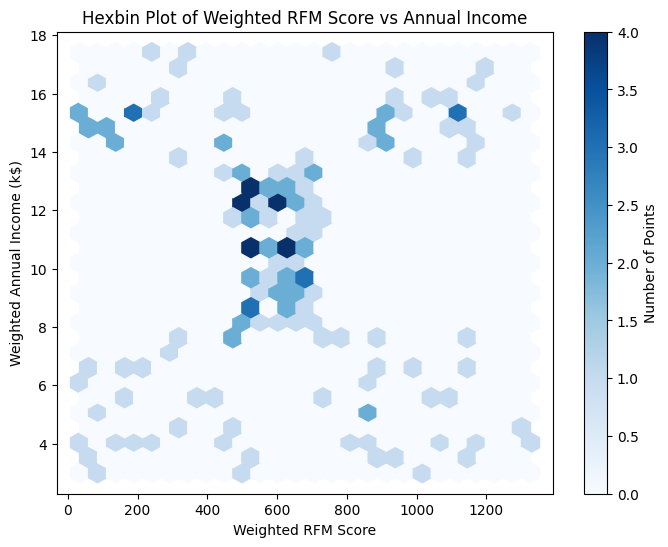

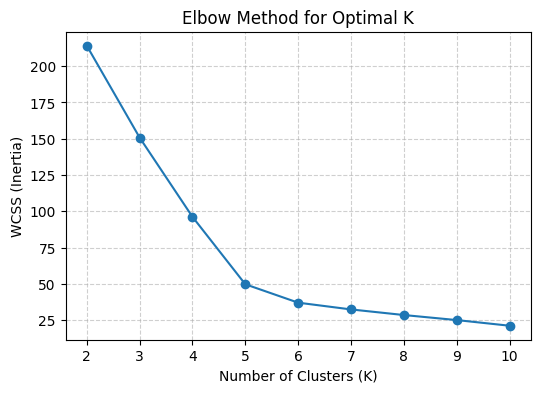


Silhouette Score for K-Means: 0.564
Davies-Bouldin Index for K-Means: 0.557

Centroids (RFM Score, Income) unweighted:

Cluster 0: (RFM Score: 747, Income: $54k)
Cluster 1: (RFM Score: 293, Income: $77k)
Cluster 2: (RFM Score: 305, Income: $25k)
Cluster 3: (RFM Score: 1284, Income: $76k)
Cluster 4: (RFM Score: 1257, Income: $25k)

Average RFM per Cluster:
             Recency (days)  Frequency (visits)  Monetary ($)
KM Cluster                                                  
0                     26.0                47.0        1783.0
1                     75.0                15.0         704.0
2                     75.0                15.0         736.0
3                      5.0                80.0        3083.0
4                      6.0                79.0        3017.0


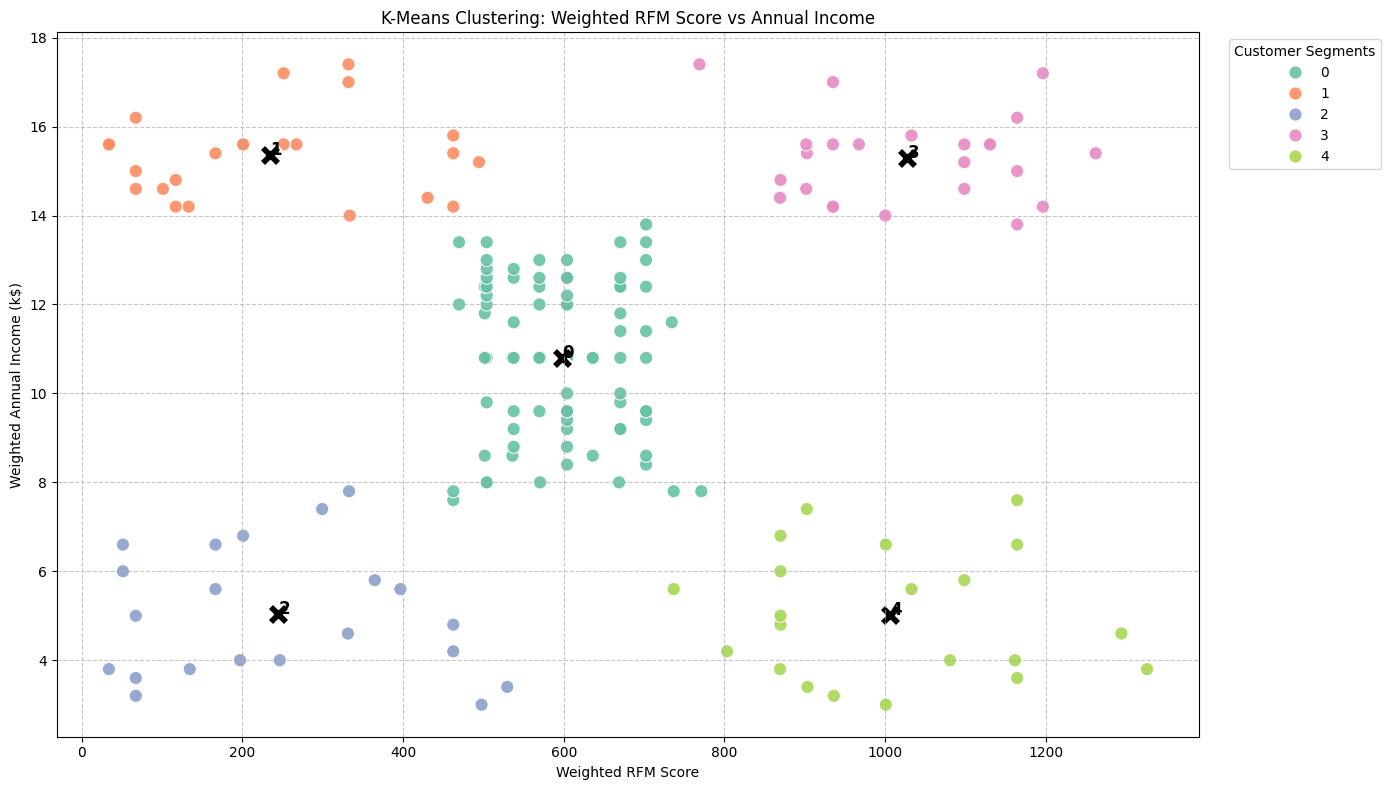


K-Means Model and Scaler saved in 'model_files/'


In [1]:
import pandas as pd
import numpy as np
import pickle
import os
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score


# Load dataset
df = pd.read_csv("customer_data.csv")

print(f'There are {df.shape[0]} rows and {df.shape[1]} columns in our dataset.')
print(df.dtypes)
print(df.isnull().sum())
print(df.duplicated().sum())
print("\nFirst 5 rows of the dataset:")
print(df.head())

# Drop irrelevant columns (SAME as MeanShift)
df.drop(
    columns=['CustomerID', 'Gender', 'Age', 'Spending Score (1-100)', 'Mail id'],
    axis=1,
    inplace=True
)

# Define weights (EXACT same as MeanShift)
WEIGHT_RECENCY = 0.2
WEIGHT_FREQUENCY = 0.4
WEIGHT_MONETARY = 0.4
WEIGHT_INCOME = 0.2   # Weight for Annual Income
WEIGHT_RFM = 0.8      # Weight for composite RFM score

# Compute composite RFM score (SAME LOGIC)
df['RFM Score'] = (WEIGHT_RECENCY * (100 - df['Recency (days)'])) + \
                  (WEIGHT_FREQUENCY * df['Frequency (visits)']) + \
                  (WEIGHT_MONETARY * df['Monetary ($)'])

# Prepare data with weighted RFM Score + Income (SAME AS MEANSHIFT)
x_rfm_income = df[['RFM Score', 'Annual Income (k$)']].copy()

# Apply weights
x_rfm_income['RFM Score'] = x_rfm_income['RFM Score'] * WEIGHT_RFM
x_rfm_income['Annual Income (k$)'] = x_rfm_income['Annual Income (k$)'] * WEIGHT_INCOME

# Add RFM components for interpretation (IMPORTANT - matches MeanShift)
x_rfm_income[['Recency (days)', 'Frequency (visits)', 'Monetary ($)']] = \
    df[['Recency (days)', 'Frequency (visits)', 'Monetary ($)']]

# Visualization of weighted data (SAME STYLE)
plt.figure(figsize=(8, 6))
plt.hexbin(
    x_rfm_income['RFM Score'],
    x_rfm_income['Annual Income (k$)'],
    gridsize=25,
    cmap='Blues'
)
plt.colorbar(label='Number of Points')
plt.xlabel('Weighted RFM Score')
plt.ylabel('Weighted Annual Income (k$)')
plt.title('Hexbin Plot of Weighted RFM Score vs Annual Income')
plt.show()

# Standardize after weighting (SAME STEP AS MEANSHIFT)
scaler = StandardScaler()
x_scaled = scaler.fit_transform(
    x_rfm_income[['RFM Score', 'Annual Income (k$)']]
)

# Elbow Method to find optimal K (K-Means specific)
wcss = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(x_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(K_range, wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method for Optimal K")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Final K-Means clustering (Using K=5 to match MeanShift clusters)
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
labels = kmeans.fit_predict(x_scaled)
x_rfm_income['KM Cluster'] = labels

# Silhouette Score (VERY IMPORTANT for evaluation)
sil_score = silhouette_score(x_scaled, labels)
print(f"\nSilhouette Score for K-Means: {sil_score:.3f}")
# Davies-Bouldin Index
dbi_kmeans = davies_bouldin_score(x_scaled, labels)
print(f"Davies-Bouldin Index for K-Means: {dbi_kmeans:.3f}")

# Calculate centroids (SAME INTERPRETATION METHOD AS MEANSHIFT)
centroids_scaled = kmeans.cluster_centers_
centroids_original = scaler.inverse_transform(centroids_scaled)
centroids_unweighted = centroids_original / np.array([WEIGHT_RFM, WEIGHT_INCOME])

print("\nCentroids (RFM Score, Income) unweighted:\n")
for i, (rfm_score, income) in enumerate(centroids_unweighted):
    print(f"Cluster {i}: (RFM Score: {rfm_score:.0f}, Income: ${income:.0f}k)")

# Average RFM per cluster (EXACT SAME AS MEANSHIFT NOTEBOOK)
cluster_rfm_means = x_rfm_income.groupby('KM Cluster')[
    ['Recency (days)', 'Frequency (visits)', 'Monetary ($)']
].mean().round(0)

print("\nAverage RFM per Cluster:\n", cluster_rfm_means)

# Visualize clusters (SAME VISUAL STYLE AS MEANSHIFT)
plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=x_rfm_income,
    x='RFM Score',
    y='Annual Income (k$)',
    hue='KM Cluster',
    palette='Set2',
    s=90,
    edgecolor='white',
    alpha=0.9
)

# Plot centroids
for i, (rfm_score, income) in enumerate(centroids_original):
    plt.scatter(
        rfm_score,
        income,
        c='black',
        s=250,
        marker='X',
        edgecolor='white',
        linewidth=1.5
    )
    plt.text(rfm_score + 0.5, income, str(i), fontsize=12, weight='bold')

plt.title('K-Means Clustering: Weighted RFM Score vs Annual Income')
plt.xlabel('Weighted RFM Score')
plt.ylabel('Weighted Annual Income (k$)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Customer Segments', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Save model + scaler (SAME FOLDER STRUCTURE AS MEANSHIFT)
os.makedirs("model_files", exist_ok=True)

with open("model_files/kmeans_model.pkl", "wb") as f:
    pickle.dump(kmeans, f)

with open("model_files/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("\nK-Means Model and Scaler saved in 'model_files/'")